In [3]:
import struct
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import confusion_matrix

In [4]:
tf.config.list_physical_devices('GPU')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [5]:
with open('./datasets/mnist/train-images.idx3-ubyte', 'rb') as f:
    _, n, rows, cols = struct.unpack('>IIII', f.read(16))
    train_images = np.fromfile(f, dtype=np.uint8).reshape(n, rows, cols)
    # RNN input: (N, time_steps, features) → channel 불필요, shape (60000, 28, 28)

with open('./datasets/mnist/train-labels.idx1-ubyte', 'rb') as f:
    struct.unpack('>II', f.read(8))
    train_labels = np.fromfile(f, dtype=np.uint8)

with open('./datasets/mnist/t10k-images.idx3-ubyte', 'rb') as f:
    _, n, rows, cols = struct.unpack('>IIII', f.read(16))
    test_images = np.fromfile(f, dtype=np.uint8).reshape(n, rows, cols)

with open('./datasets/mnist/t10k-labels.idx1-ubyte', 'rb') as f:
    struct.unpack('>II', f.read(8))
    test_labels = np.fromfile(f, dtype=np.uint8)

# uint8(0 ~ 255) -> float32(0.0 ~ 1.0) 정규화
train_images = train_images.astype(np.float32) / 255.0
test_images  = test_images.astype(np.float32)  / 255.0

In [6]:
train_dataset = tf.data.Dataset.from_tensor_slices((train_images, train_labels))
test_dataset  = tf.data.Dataset.from_tensor_slices((test_images,  test_labels))

# shuffle(): 학습 데이터 순서를 섞어 편향 방지
# prefetch(): 다음 batch를 background에서 미리 load → GPU 대기 시간 감소
train_dataset = train_dataset.shuffle(1000).batch(64).prefetch(tf.data.AUTOTUNE)
test_dataset  = test_dataset.batch(64).prefetch(tf.data.AUTOTUNE)

I0000 00:00:1781058284.482027  101922 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:1e.0, compute capability: 7.5


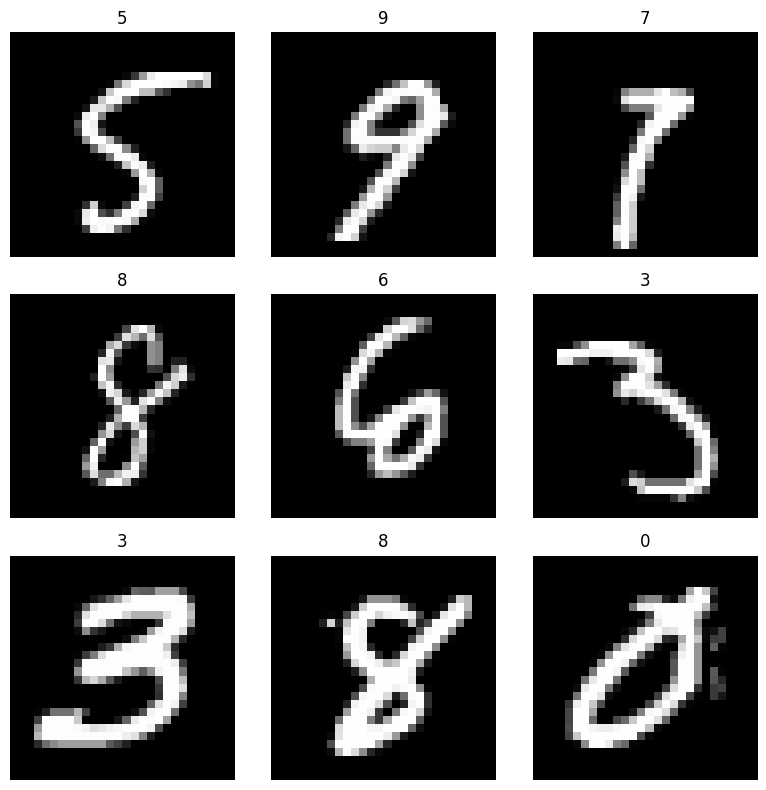

In [7]:
CLASSES = tuple(str(i) for i in range(10))

sample_images, sample_labels = next(iter(train_dataset))

figure = plt.figure(figsize=(8, 8))
indices = np.random.choice(sample_images.shape[0], 9, replace=False)

for i, idx in enumerate(indices, 1):
    figure.add_subplot(3, 3, i)
    plt.title(CLASSES[sample_labels[idx].numpy()])
    plt.axis("off")
    plt.imshow(sample_images[idx].numpy(), cmap="gray")

plt.tight_layout()
plt.show()

**layers.SimpleRNN(units, return_sequences, activation, dropout, recurrent_dropout)**
* **unit**: hidden state 크기. 128 시작 → 성능 부족 시 *2, overfitting 시 /2
* **return_sequences**: 중간 RNN 레이어: True (모든 time step 반환), 마지막: False (many-to-one)
* **activation**: 기본값 'tanh'. gradient exploding 우려로 'relu' 지양
* **dropout**: 입력(x_t)에 적용하는 dropout 비율
* **recurrent_dropout**: hidden state(h_t)에 적용하는 dropout 비율

In [8]:
def RNN():
    inputs = keras.Input(shape=(28, 28))  # (time_steps=28, features=28)

    # Layer 1: return_sequences=True → 모든 time step의 hidden state를 다음 RNN 레이어로 전달
    x = layers.SimpleRNN(128, return_sequences=True, activation='tanh', dropout=0.3)(inputs)

    # Layer 2: return_sequences=False → 마지막 time step의 hidden state만 반환 (many-to-one)
    x = layers.SimpleRNN(64, return_sequences=False, activation='tanh', dropout=0.3)(x)

    # Classifier
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(10)(x)  # logits (softmax는 loss 함수 내부에서 처리)

    return keras.Model(inputs, outputs, name="rnn_mnist")


model = RNN()
model.summary()

Model: "rnn_mnist"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 28, 128)        │        20,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37,258 (145.54 KB)

 Trainable params: 37,258 (145.54 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

callbacks = [
    # val_loss가 3 epoch 동안 개선되지 않으면 학습 조기 종료
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True  # 가장 좋은 가중치로 자동 복원
    ),
    # val_loss가 개선되지 않으면 learning rate를 0.5배로 감소
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    ),
]

history = model.fit(
    train_dataset,
    epochs=10,
    validation_data=test_dataset,
    callbacks=callbacks,
)

Epoch 1/10


I0000 00:00:1781058288.773744  102193 service.cc:153] XLA service 0x563e631b94e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781058288.773768  102193 service.cc:161]   StreamExecutor [0]: Tesla T4, Compute Capability 7.5 (Driver: 13.0.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.23.1)
I0000 00:00:1781058288.827225  102193 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1781058289.125792  102193 cuda_dnn.cc:461] Loaded cuDNN version 92301
I0000 00:00:1781058289.256871  102193 dot_merger.cc:481] Merging Dots in computation: rnn_mnist_1_simple_rnn_1_2_while_body_2359_grad_2570_const_0__.26.clone.clone.clone.clone.clone.clone.clone.clone
I0000 00:00:1781058289.256984  102193 dot_merger.cc:481] Merging Dots in computation: rnn_mnist_1_simple_rnn_1_while_body_2216_grad_2841_const_0__.33.clone.clone.clone.clone.clone.clone
I0000 00:00:1781058289.257049  102193 d

 30/938 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.2111 - loss: 2.2061

I0000 00:00:1781058291.794663  102193 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


934/938 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6417 - loss: 1.0731

I0000 00:00:1781058297.320328  102192 dot_merger.cc:481] Merging Dots in computation: rnn_mnist_1_simple_rnn_1_2_while_body_2359_grad_2570_const_0__.26.clone.clone.clone.clone.clone.clone.clone.clone
I0000 00:00:1781058297.320436  102192 dot_merger.cc:481] Merging Dots in computation: rnn_mnist_1_simple_rnn_1_while_body_2216_grad_2841_const_0__.33.clone.clone.clone.clone.clone.clone
I0000 00:00:1781058297.320496  102192 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_3451__.34


938/938 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - accuracy: 0.7648 - loss: 0.7384 - val_accuracy: 0.9310 - val_loss: 0.2415 - learning_rate: 0.0010
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8826 - loss: 0.4101 - val_accuracy: 0.9419 - val_loss: 0.2000 - learning_rate: 0.0010
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9057 - loss: 0.3351 - val_accuracy: 0.9503 - val_loss: 0.1749 - learning_rate: 0.0010
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9123 - loss: 0.3145 - val_accuracy: 0.9527 - val_loss: 0.1696 - learning_rate: 0.0010
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9219 - loss: 0.2906 - val_accuracy: 0.9548 - val_loss: 0.1575 - learning_rate: 0.0010
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9219 - loss: 0.2857 - val_accuracy: 0.9577 - val_loss: 0.1492 - learning_rate: 0.0010
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9258 - loss: 0.2733 - val_accur

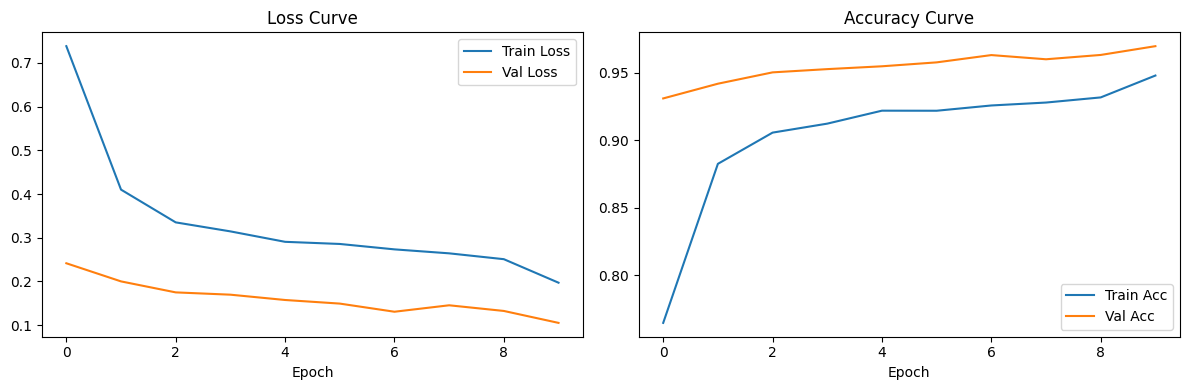

In [10]:
hist = history.history

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(hist["loss"],     label="Train Loss")
ax1.plot(hist["val_loss"], label="Val Loss")
ax1.set_title("Loss Curve")
ax1.set_xlabel("Epoch")
ax1.legend()

ax2.plot(hist["accuracy"],     label="Train Acc")
ax2.plot(hist["val_accuracy"], label="Val Acc")
ax2.set_title("Accuracy Curve")
ax2.set_xlabel("Epoch")
ax2.legend()

plt.tight_layout()
plt.show()

Test Loss: 0.1051 | Test Accuracy: 0.9697


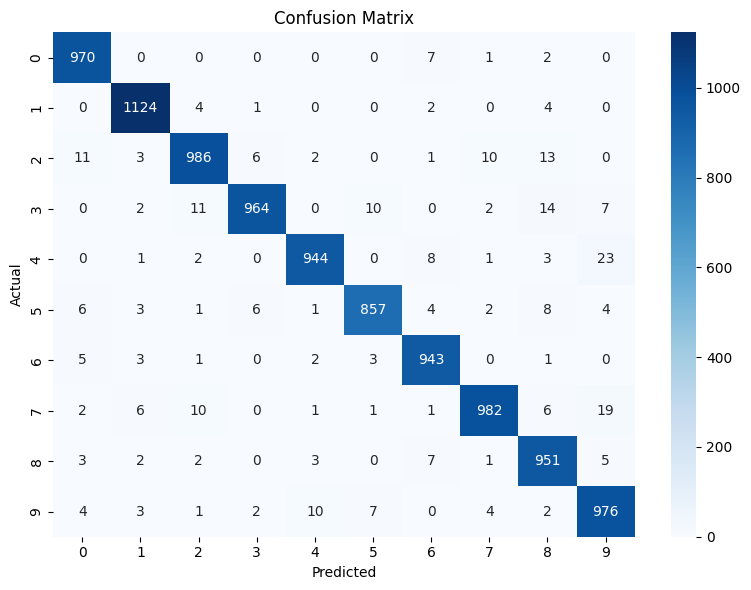

In [11]:
test_loss, test_acc = model.evaluate(test_dataset, verbose=0)
print(f"Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc:.4f}")

all_preds  = []
all_labels = []

for images, labels in test_dataset:
    logits = model(images, training=False)  # training=False: Dropout 비활성화
    preds  = tf.argmax(logits, axis=1).numpy()
    all_preds.extend(preds)
    all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=CLASSES, yticklabels=CLASSES,
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

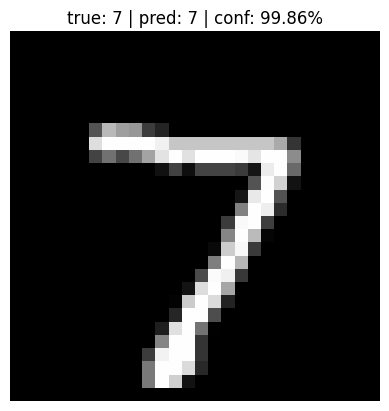

In [12]:
sample_images, sample_labels = next(iter(test_dataset))

idx          = 0
single_image = sample_images[idx:idx+1]  # (1, 28, 28) shape 유지
true_label   = sample_labels[idx].numpy()

logits     = model(single_image, training=False)
probs      = tf.nn.softmax(logits, axis=1).numpy()[0]
pred_label = np.argmax(probs)
confidence = probs[pred_label]

plt.imshow(single_image[0].numpy(), cmap="gray")
plt.title(
    f"true: {CLASSES[true_label]} | "
    f"pred: {CLASSES[pred_label]} | "
    f"conf: {confidence:.2%}"
)
plt.axis("off")
plt.show()